In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

## Mapping individual receptive fields

In this notebook we will map the tactile receptive fields of 23B neurons with respect to the synaptic input they receive from first-order bristle mechanosensory neurons. This analysis is dependent on mapping each bristle neuron to a relative location on the leg. If you are interested in how this mapping was performed, please see the notebook `Spatial_Mapping_in_FANC`. 

Note: This analysis is not specific to 23B neurons, and can be applied to any central neuron that receives input from bristle mechanosensory neurons.

In [2]:
edge_df = pd.read_pickle('../data/bristle_downstream_connectivity_1125.pkl')
syn_df = pd.read_pickle('../data/bristle_downstream_synapses_1125.pkl')
syn_df.shape

(225422, 27)

In [3]:
#Ensuring that the synapse dataframe only contains synapses from neurons that pass the synapse threshold
syn_df = syn_df[syn_df['post_pt_root_id'].isin(edge_df['post_pt_root_id'].unique())]

In [21]:
#df that only contains bristle synapses onto 23B neurons
bee_df = syn_df.copy()
bee_df = bee_df[bee_df.subtype_23B.notnull()]
bees = bee_df.post_pt_root_id.unique()

In [22]:
#Calculating receptive field means and sems for each 23B neuron
pd_rf_mean_dict = bee_df.groupby('post_pt_root_id').bristle_pd_avg.mean().sort_values(ascending=False).to_dict()
pd_rf_sem_dict = bee_df.groupby('post_pt_root_id').bristle_pd_avg.sem().sort_values(ascending=False).to_dict()

bee_df['rf_mean_pd'] = bee_df.post_pt_root_id.map(pd_rf_mean_dict)
bee_df['rf_sem_pd'] = bee_df.post_pt_root_id.map(pd_rf_sem_dict)

dv_rf_mean_dict = bee_df.groupby('post_pt_root_id').bristle_dv_avg.mean().sort_values(ascending=False).to_dict()
dv_rf_sem_dict = bee_df.groupby('post_pt_root_id').bristle_dv_avg.sem().sort_values(ascending=False).to_dict()

bee_df['rf_mean_dv'] = bee_df.post_pt_root_id.map(dv_rf_mean_dict)
bee_df['rf_sem_dv'] = bee_df.post_pt_root_id.map(dv_rf_sem_dict)

ap_rf_mean_dict = bee_df.groupby('post_pt_root_id').bristle_ap_binary.mean().sort_values(ascending=False).to_dict()
ap_rf_sem_dict = bee_df.groupby('post_pt_root_id').bristle_ap_binary.sem().sort_values(ascending=False).to_dict()

bee_df['rf_mean_ap'] = bee_df.post_pt_root_id.map(ap_rf_mean_dict)
bee_df['rf_sem_ap'] = bee_df.post_pt_root_id.map(ap_rf_sem_dict)

### Receptive Fields for two example neurons

In [23]:
#Anterior Posterior Palette
ap_palette = sns.color_palette("ch:s=.25,rot=-.25",2).as_hex()

#Dorsal Ventral Palette
dv_palette = sns.cubehelix_palette(reverse=True, as_cmap=True)

#Proximal Distal Palette
pd_palette = sns.cubehelix_palette(start=2, rot=0, dark=0.1, light=.9, reverse=True, as_cmap=True)


Here are two example neurons to illustrate the process of mapping receptive fields. One neuron has a distal receptive field, while the other has a proximal receptive field. (These neurons were chosen arbitrarily for illustration purposes but are consistent with the neurons presented in Figure 3 of the accompanying manuscript).

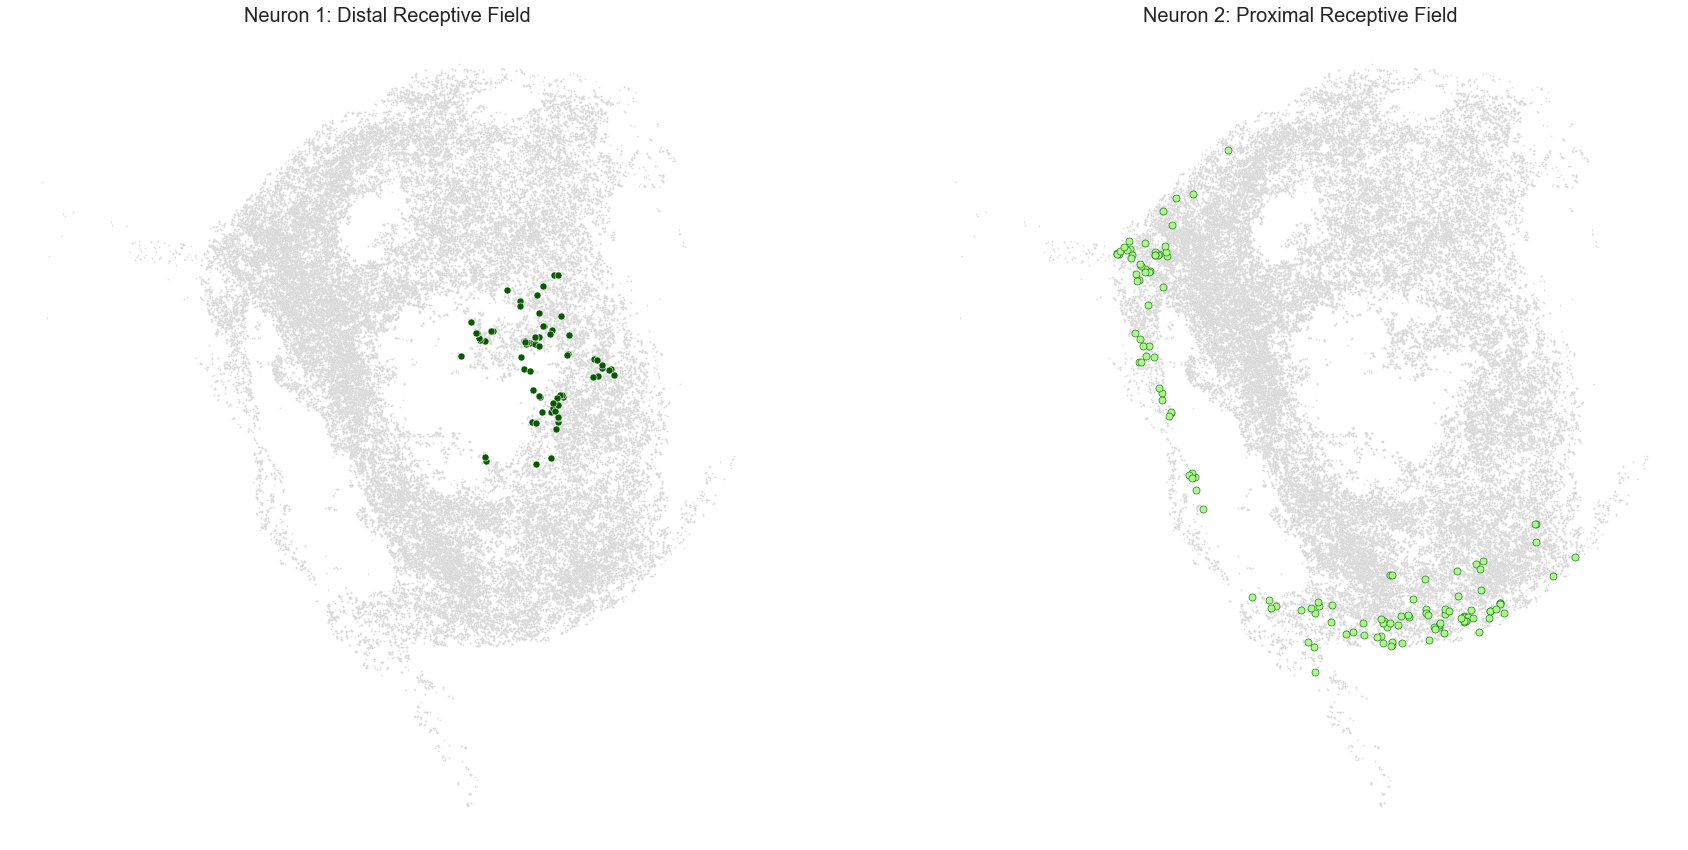

In [24]:

example = 648518346486107332
subset = syn_df.query('post_pt_root_id == @example')


pd_min = syn_df.bristle_pd_avg.min()
pd_max = syn_df.bristle_pd_avg.max()

fig, ax = plt.subplots(1,2,figsize=(30,15))
sns.scatterplot(x='pre_pt_position_x', y='pre_pt_position_y', data =syn_df,
                s=3,alpha=0.8, color='lightgray', ax=ax[0])

sns.scatterplot(x='pre_pt_position_x', y='pre_pt_position_y', data =subset,
            s=50,alpha=1, color = '#095903', edgecolor='white',
            ax=ax[0], legend =False)


ax[0].invert_xaxis()
ax[0].invert_yaxis()
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Neuron 1: Distal Receptive Field', fontsize=20)

example = 648518346492579779
subset = syn_df.query('post_pt_root_id == @example')


sns.scatterplot(x='pre_pt_position_x', y='pre_pt_position_y', data =syn_df,
                s=3,alpha=0.8, color='lightgray', ax=ax[1])


sns.scatterplot(x='pre_pt_position_x', y='pre_pt_position_y', data =subset,
            s=50,alpha=1, color = '#acf88b', edgecolor='darkgreen',
            ax=ax[1], legend =False)
#ax.scatter(x= pd_point[0], y=pd_point[1], s=200,alpha=1,color='darkred',linewidth=2,edgecolor='white')
ax[1].invert_xaxis()
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Neuron 2: Proximal Receptive Field', fontsize=20)

sns.despine(fig=None, ax=None, top=True, right=True, left=True, bottom=True, offset=None, trim=False)

plt.show()

Note that these receptive fields are all relative locations on the leg, not absolute locations. You will notice that that y axes are synapse distances. For the proximal to distal axis, bristle neurons that are closer to the mapping point (shorter synapse distance) are more distal on the leg than those that are farther away. Along the dorsal to ventral axis, bristle neurons that are closer to the mapping point (shorter synapse distance) are more dorsal while those that are farther away are more ventral on the leg. 

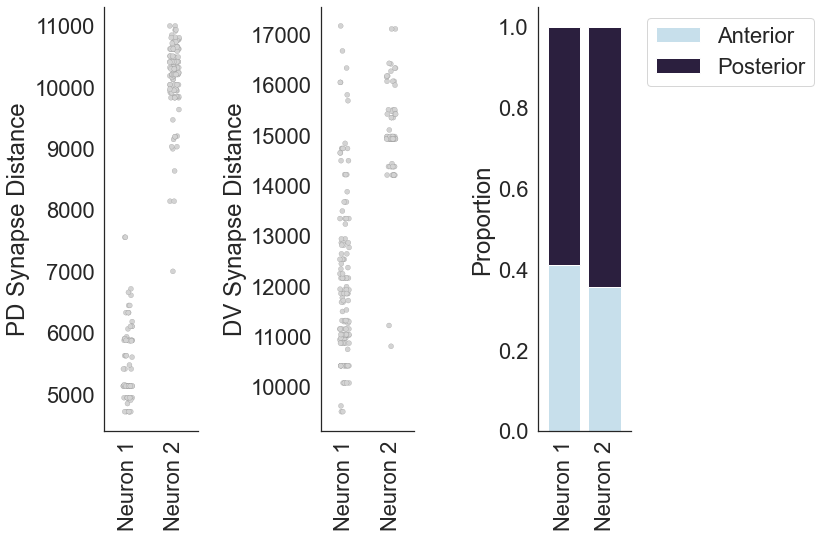

In [25]:
sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(1,3,figsize=(12,8))

examples = [648518346486107332,648518346492579779]


sns.stripplot(x='post_pt_root_id', y='bristle_pd_avg',s=5,color='lightgray',
              edgecolor='gray',linewidth=0.2, data = bee_df.query('post_pt_root_id in @examples'), ax=ax[0],jitter=True)


sns.stripplot(x='post_pt_root_id', y='bristle_dv_avg',s=5,color='lightgray',
              edgecolor='gray',linewidth=0.2, data = bee_df.query('post_pt_root_id in @examples'), ax=ax[1],jitter=True)



stacked_data = bee_df.query('post_pt_root_id in @examples').groupby(['rf_mean_ap', 'bristle_ap_binary']).size().unstack(fill_value=0)
stacked_data = stacked_data.div(stacked_data.sum(axis=1), axis=0)  # Normalize to proportions

# Plot the stacked barplot
stacked_data.plot(kind='bar', stacked=True, color=[ap_palette[0], ap_palette[1]], ax=ax[2], width=0.8)

# Customize the plot
ax[2].set_ylabel('Proportion')
ax[2].legend(labels=['Anterior', 'Posterior'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].set_xticklabels(['Neuron 1', 'Neuron 2'])
ax[2].set_xlabel('')

ax[0].set_xlabel('')
ax[0].set_ylabel('PD Synapse Distance')
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_xticklabels(['Neuron 1', 'Neuron 2'], rotation=90)

ax[1].set_xlabel('')
ax[1].set_ylabel('DV Synapse Distance')
ax[1].invert_xaxis()
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].set_xticklabels(['Neuron 2', 'Neuron 1'], rotation=90)

plt.tight_layout()
plt.show()

In [26]:
#Anterior Posterior Palette
ap_palette = sns.color_palette("ch:s=.25,rot=-.25",2).as_hex()

#Dorsal Ventral Palette
dv_palette = sns.cubehelix_palette(59, reverse=True, as_cmap=False)

#Proximal Distal Palette
pd_palette = sns.cubehelix_palette(59, start=2, rot=0, dark=0.1, light=.9, reverse=True, as_cmap=False)

### Receptive Fields for all individual 23B neurons

Now let's do the same thing shown above for all 23B neurons.

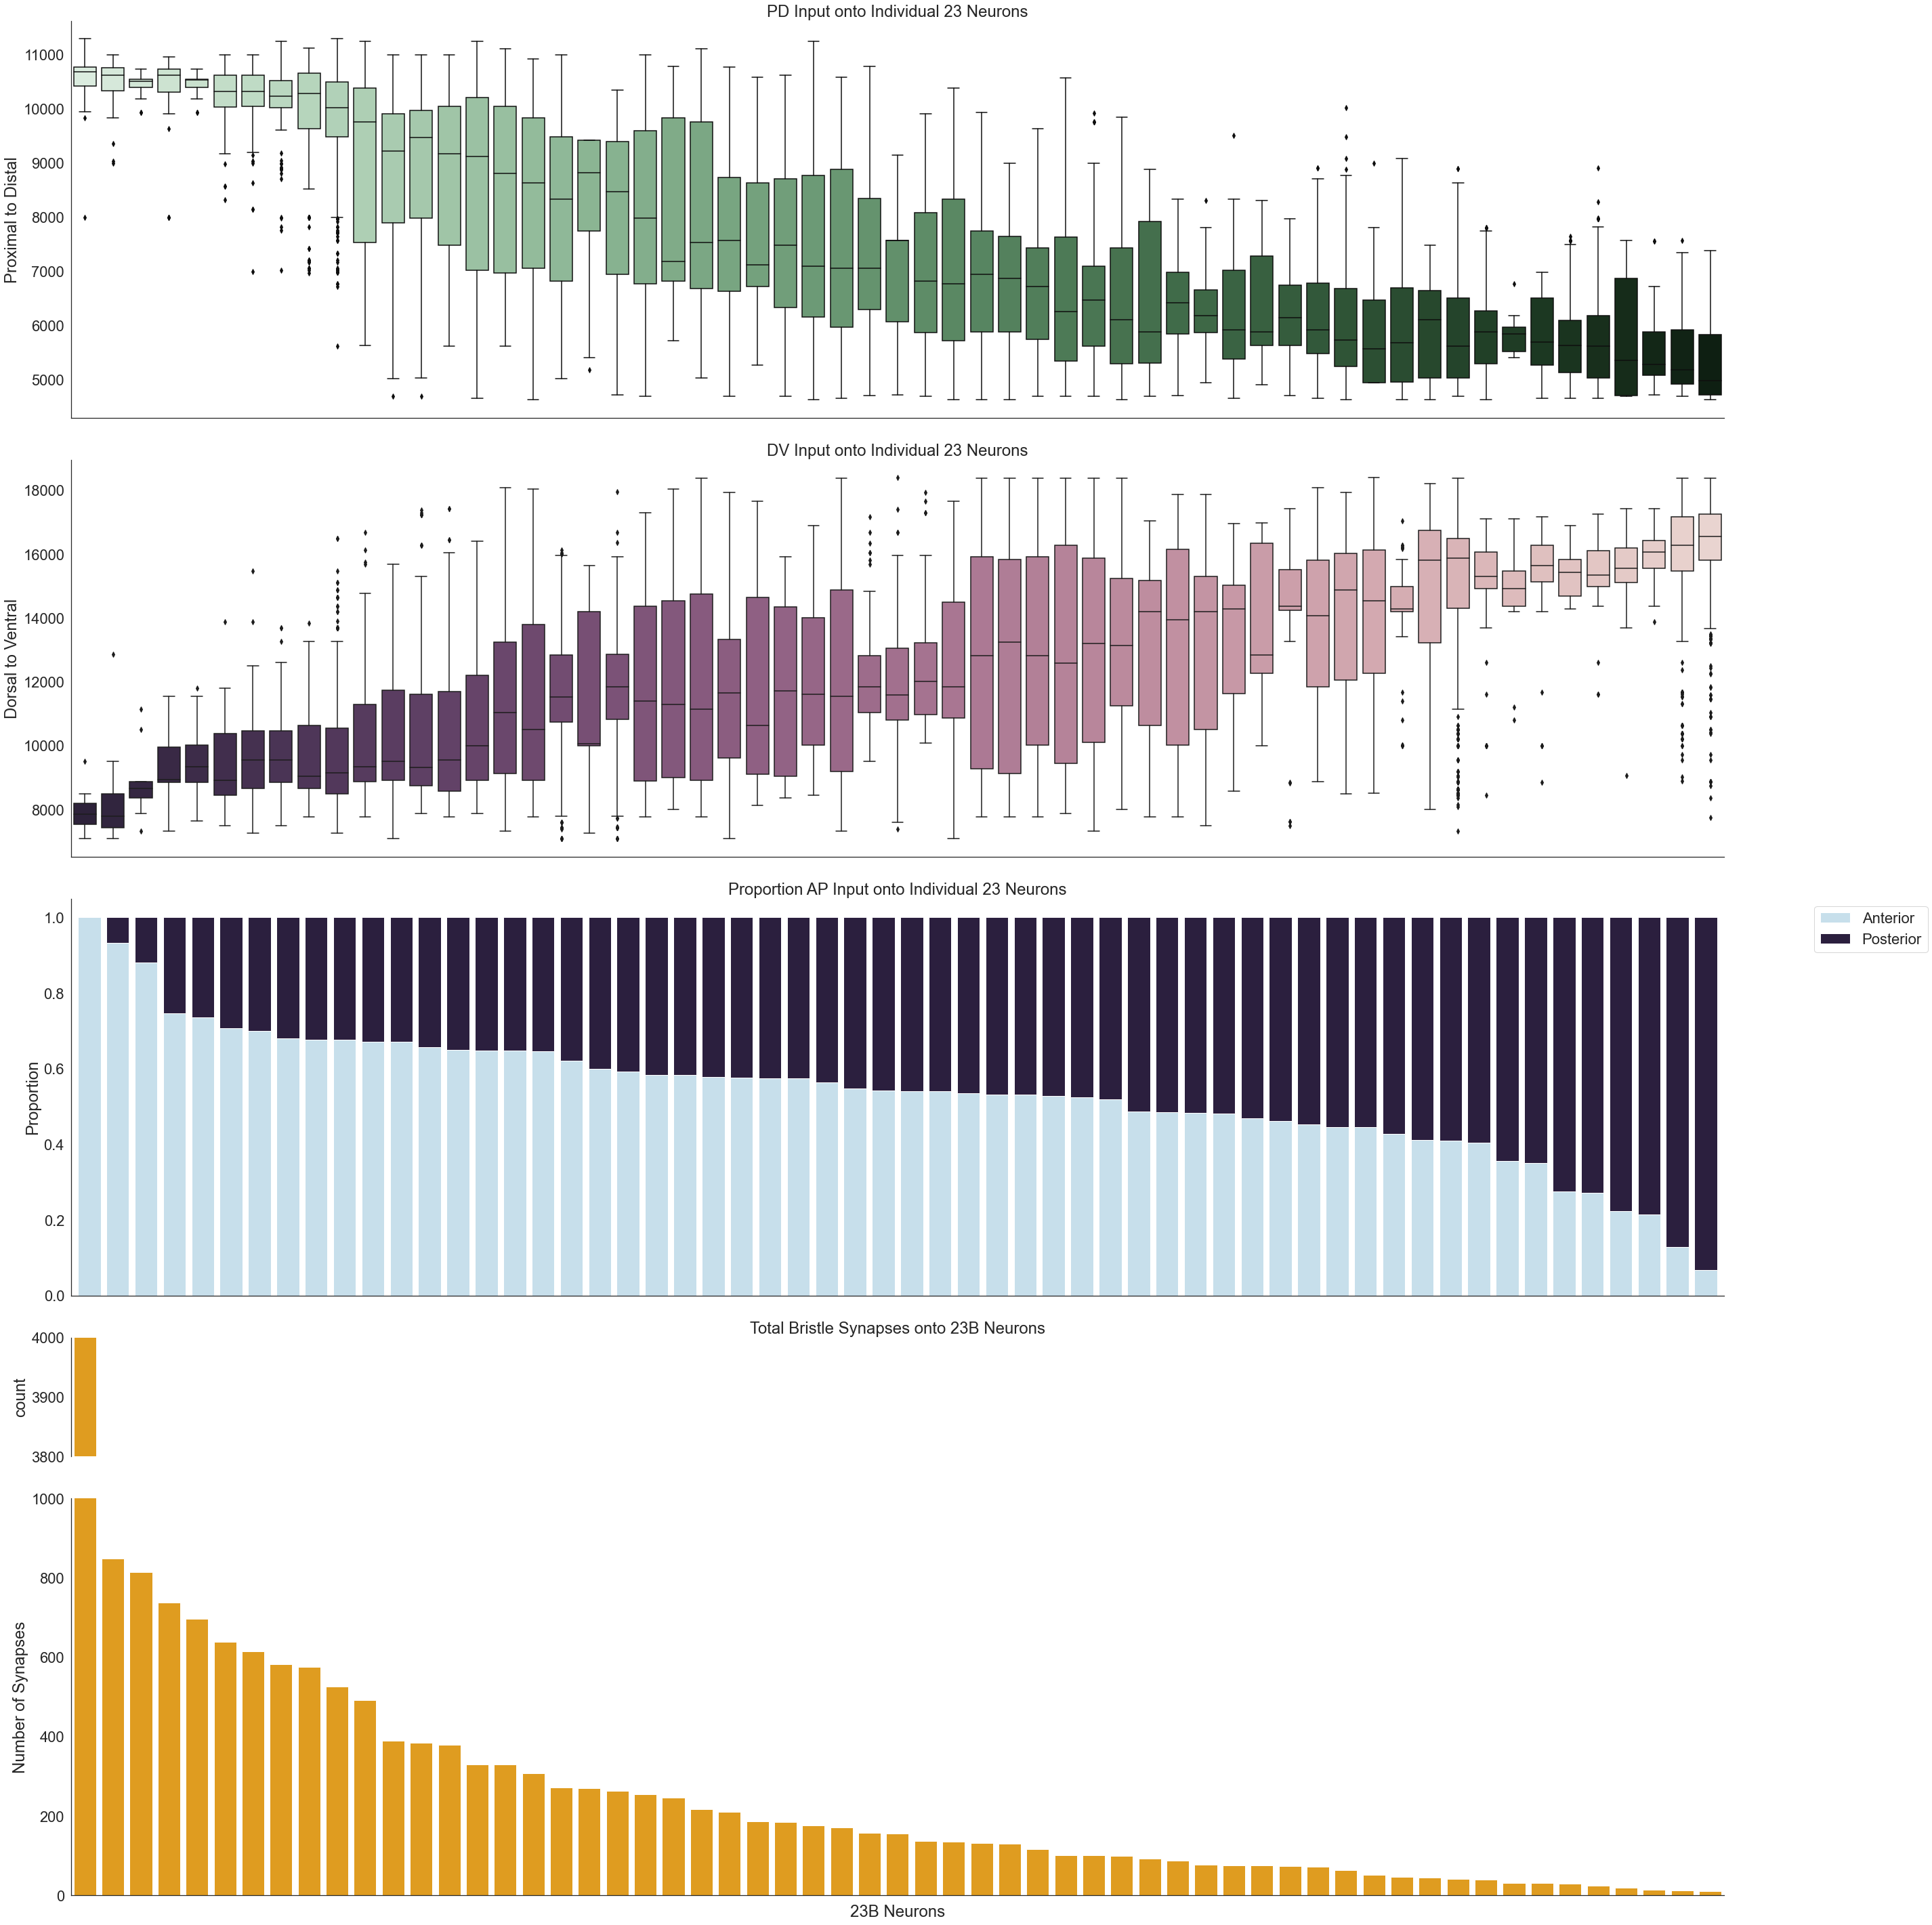

In [27]:
sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(5,1,figsize=(40,40), gridspec_kw={'height_ratios': [1, 1, 1, 0.3, 1]})

sns.boxplot(x='rf_mean_pd', y='bristle_pd_avg',palette=pd_palette,
              data = bee_df, ax=ax[0])

ax[0].set_xticklabels([])
ax[0].set_xlabel('')
ax[0].set_ylabel('Proximal to Distal')
ax[0].invert_xaxis()
ax[0].set_title('PD Input onto Individual 23 Neurons')
ax[0].spines[['right', 'top']].set_visible(False)

sns.boxplot(x='rf_mean_dv', y='bristle_dv_avg',palette=dv_palette,
            data = bee_df, ax=ax[1])

ax[1].set_xticklabels([])
ax[1].set_xlabel('')
ax[1].set_ylabel('Dorsal to Ventral')
ax[1].set_title('DV Input onto Individual 23 Neurons')
ax[1].spines[['right', 'top']].set_visible(False)

# Prepare data for the stacked barplot
stacked_data = bee_df.groupby(['rf_mean_ap', 'bristle_ap_binary']).size().unstack(fill_value=0)
stacked_data = stacked_data.div(stacked_data.sum(axis=1), axis=0)  # Normalize to proportions

# Plot the stacked barplot
stacked_data.plot(kind='bar', stacked=True, color=[ap_palette[0], ap_palette[1]], ax=ax[2], width=0.8)

# Customize the plot
ax[2].set_ylabel('Proportion')
ax[2].set_xlabel('Neuron')
ax[2].set_title('Proportion AP Input onto Individual 23 Neurons')
ax[2].legend(labels=['Anterior', 'Posterior'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].set_xticklabels([])
ax[2].set_xlabel('')

size_df = bee_df.groupby('post_pt_root_id').size().reset_index(name='count')
size_df = size_df.sort_values('count', ascending=False)
size_df['count_order'] = np.arange(len(size_df))

sns.barplot(x='count_order', y='count', data=size_df.sort_values('count', ascending=False),
            color = 'orange', ax=ax[3])
ax[3].set_ylim(3800,4000)
ax[3].set_xticklabels([])
ax[3].set_xlabel('')
ax[3].set_title('Total Bristle Synapses onto 23B Neurons')
ax[3].spines[['right', 'top', 'bottom']].set_visible(False)

sns.barplot(x='count_order', y='count', data=size_df.sort_values('count', ascending=False),
            color = 'orange', ax=ax[4])

ax[4].set_ylim(0, 1000)
ax[4].set_ylabel('Number of Synapses')
ax[4].set_xlabel('23B Neurons')
ax[4].set_xticklabels([])
ax[4].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

#### How is the map of the leg represented with respect to the 23B neurons?

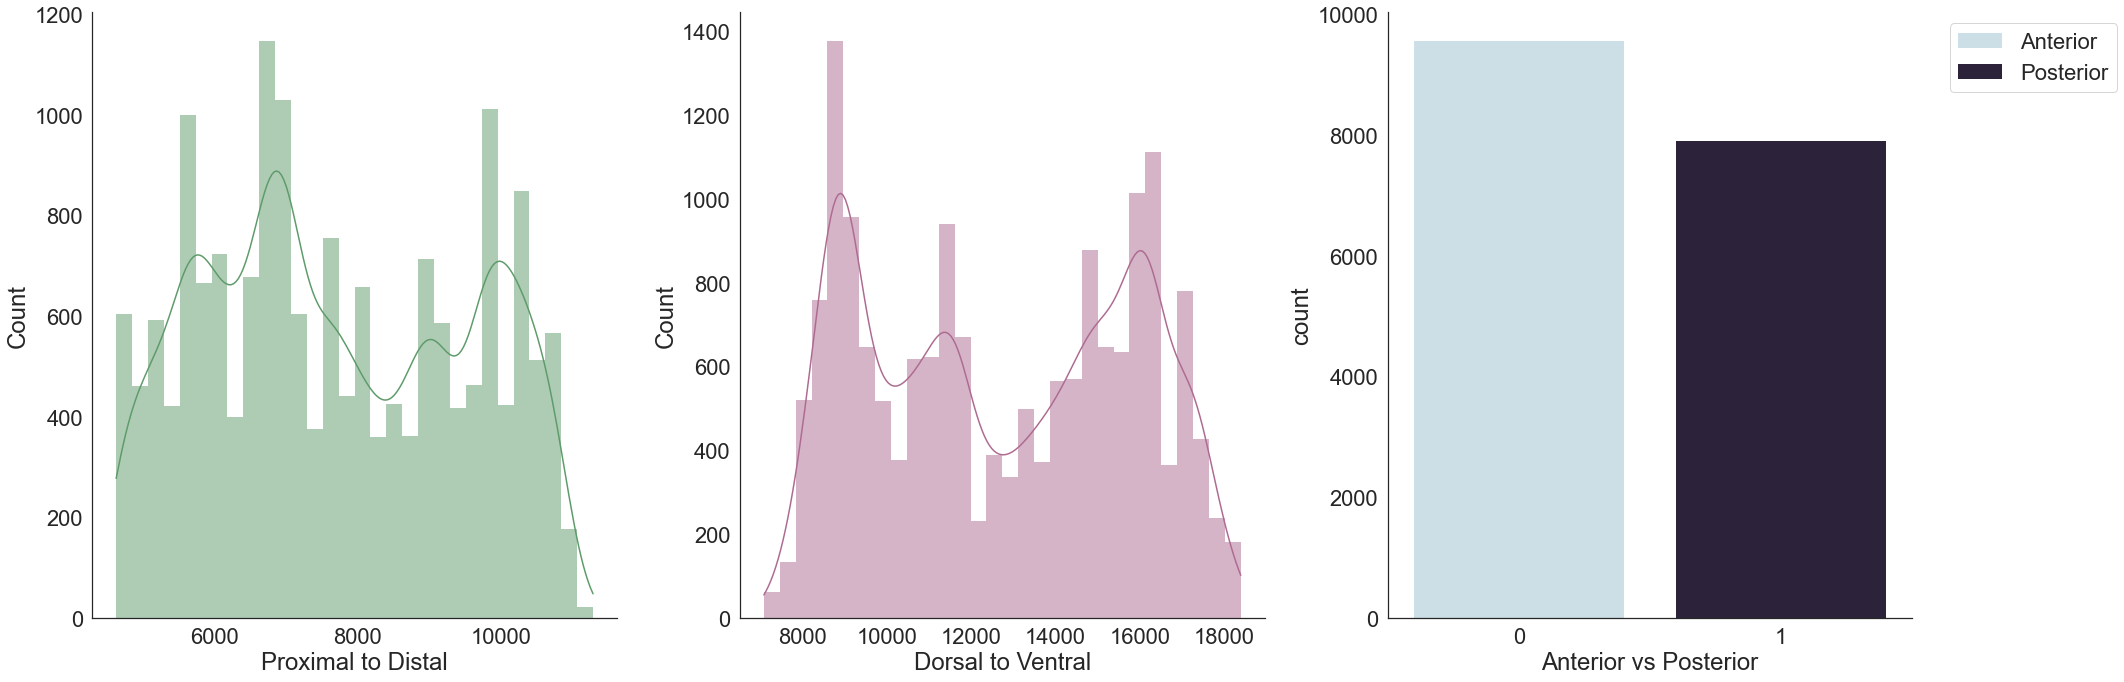

In [28]:
sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(1,3,figsize=(30,10))

sns.histplot(x='bristle_pd_avg', data = bee_df, bins=30, kde=True, color=pd_palette[30],
             edgecolor='gray', linewidth=0.0, ax=ax[0])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_xlabel('Proximal to Distal')

sns.histplot(x='bristle_dv_avg', data = bee_df, bins=30, kde=True, color=dv_palette[30],
             edgecolor='gray', linewidth=0.0, ax=ax[1])
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].set_xlabel('Dorsal to Ventral')

sns.countplot(x='bristle_ap_binary', data = bee_df, palette=ap_palette, hue='bristle_ap_binary',dodge=False,
             edgecolor='gray', linewidth=0.0, ax=ax[2])
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].set_xlabel('Anterior vs Posterior')
ax[2].legend(labels=['Anterior', 'Posterior'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Average receptive fields for each 23B subtype

In [29]:
#calculating receptive field means and sems for each 23B subtype
pd_rf_mean_dict = bee_df.groupby('subtype_23B').bristle_pd_avg.mean().sort_values(ascending=False).to_dict()
pd_rf_sem_dict = bee_df.groupby('subtype_23B').bristle_pd_avg.sem().sort_values(ascending=False).to_dict()

bee_df['subtype_rf_mean_pd'] = bee_df.subtype_23B.map(pd_rf_mean_dict)
bee_df['subtype_rf_sem_pd'] = bee_df.subtype_23B.map(pd_rf_sem_dict)

dv_rf_mean_dict = bee_df.groupby('subtype_23B').bristle_dv_avg.mean().sort_values(ascending=False).to_dict()
dv_rf_sem_dict = bee_df.groupby('subtype_23B').bristle_dv_avg.sem().sort_values(ascending=False).to_dict()

bee_df['subtype_rf_mean_dv'] = bee_df.subtype_23B.map(dv_rf_mean_dict)
bee_df['subtype_rf_sem_dv'] = bee_df.subtype_23B.map(dv_rf_sem_dict)

ap_rf_mean_dict = bee_df.groupby('subtype_23B').bristle_ap_binary.mean().sort_values(ascending=False).to_dict()
ap_rf_sem_dict = bee_df.groupby('subtype_23B').bristle_ap_binary.sem().sort_values(ascending=False).to_dict()

bee_df['subtype_rf_mean_ap'] = bee_df.subtype_23B.map(ap_rf_mean_dict)
bee_df['subtype_rf_sem_ap'] = bee_df.subtype_23B.map(ap_rf_sem_dict)

In [30]:
#Anterior Posterior Palette
ap_palette = sns.color_palette("ch:s=.25,rot=-.25",2).as_hex()

#Dorsal Ventral Palette
dv_palette = sns.cubehelix_palette(13, reverse=True, as_cmap=False)

#Proximal Distal Palette
pd_palette = sns.cubehelix_palette(13, start=2, rot=0, dark=0.1, light=.9, reverse=True, as_cmap=False)

First, let's order it by the receptive field of each subtype to illustrate the overall coverage of the leg space

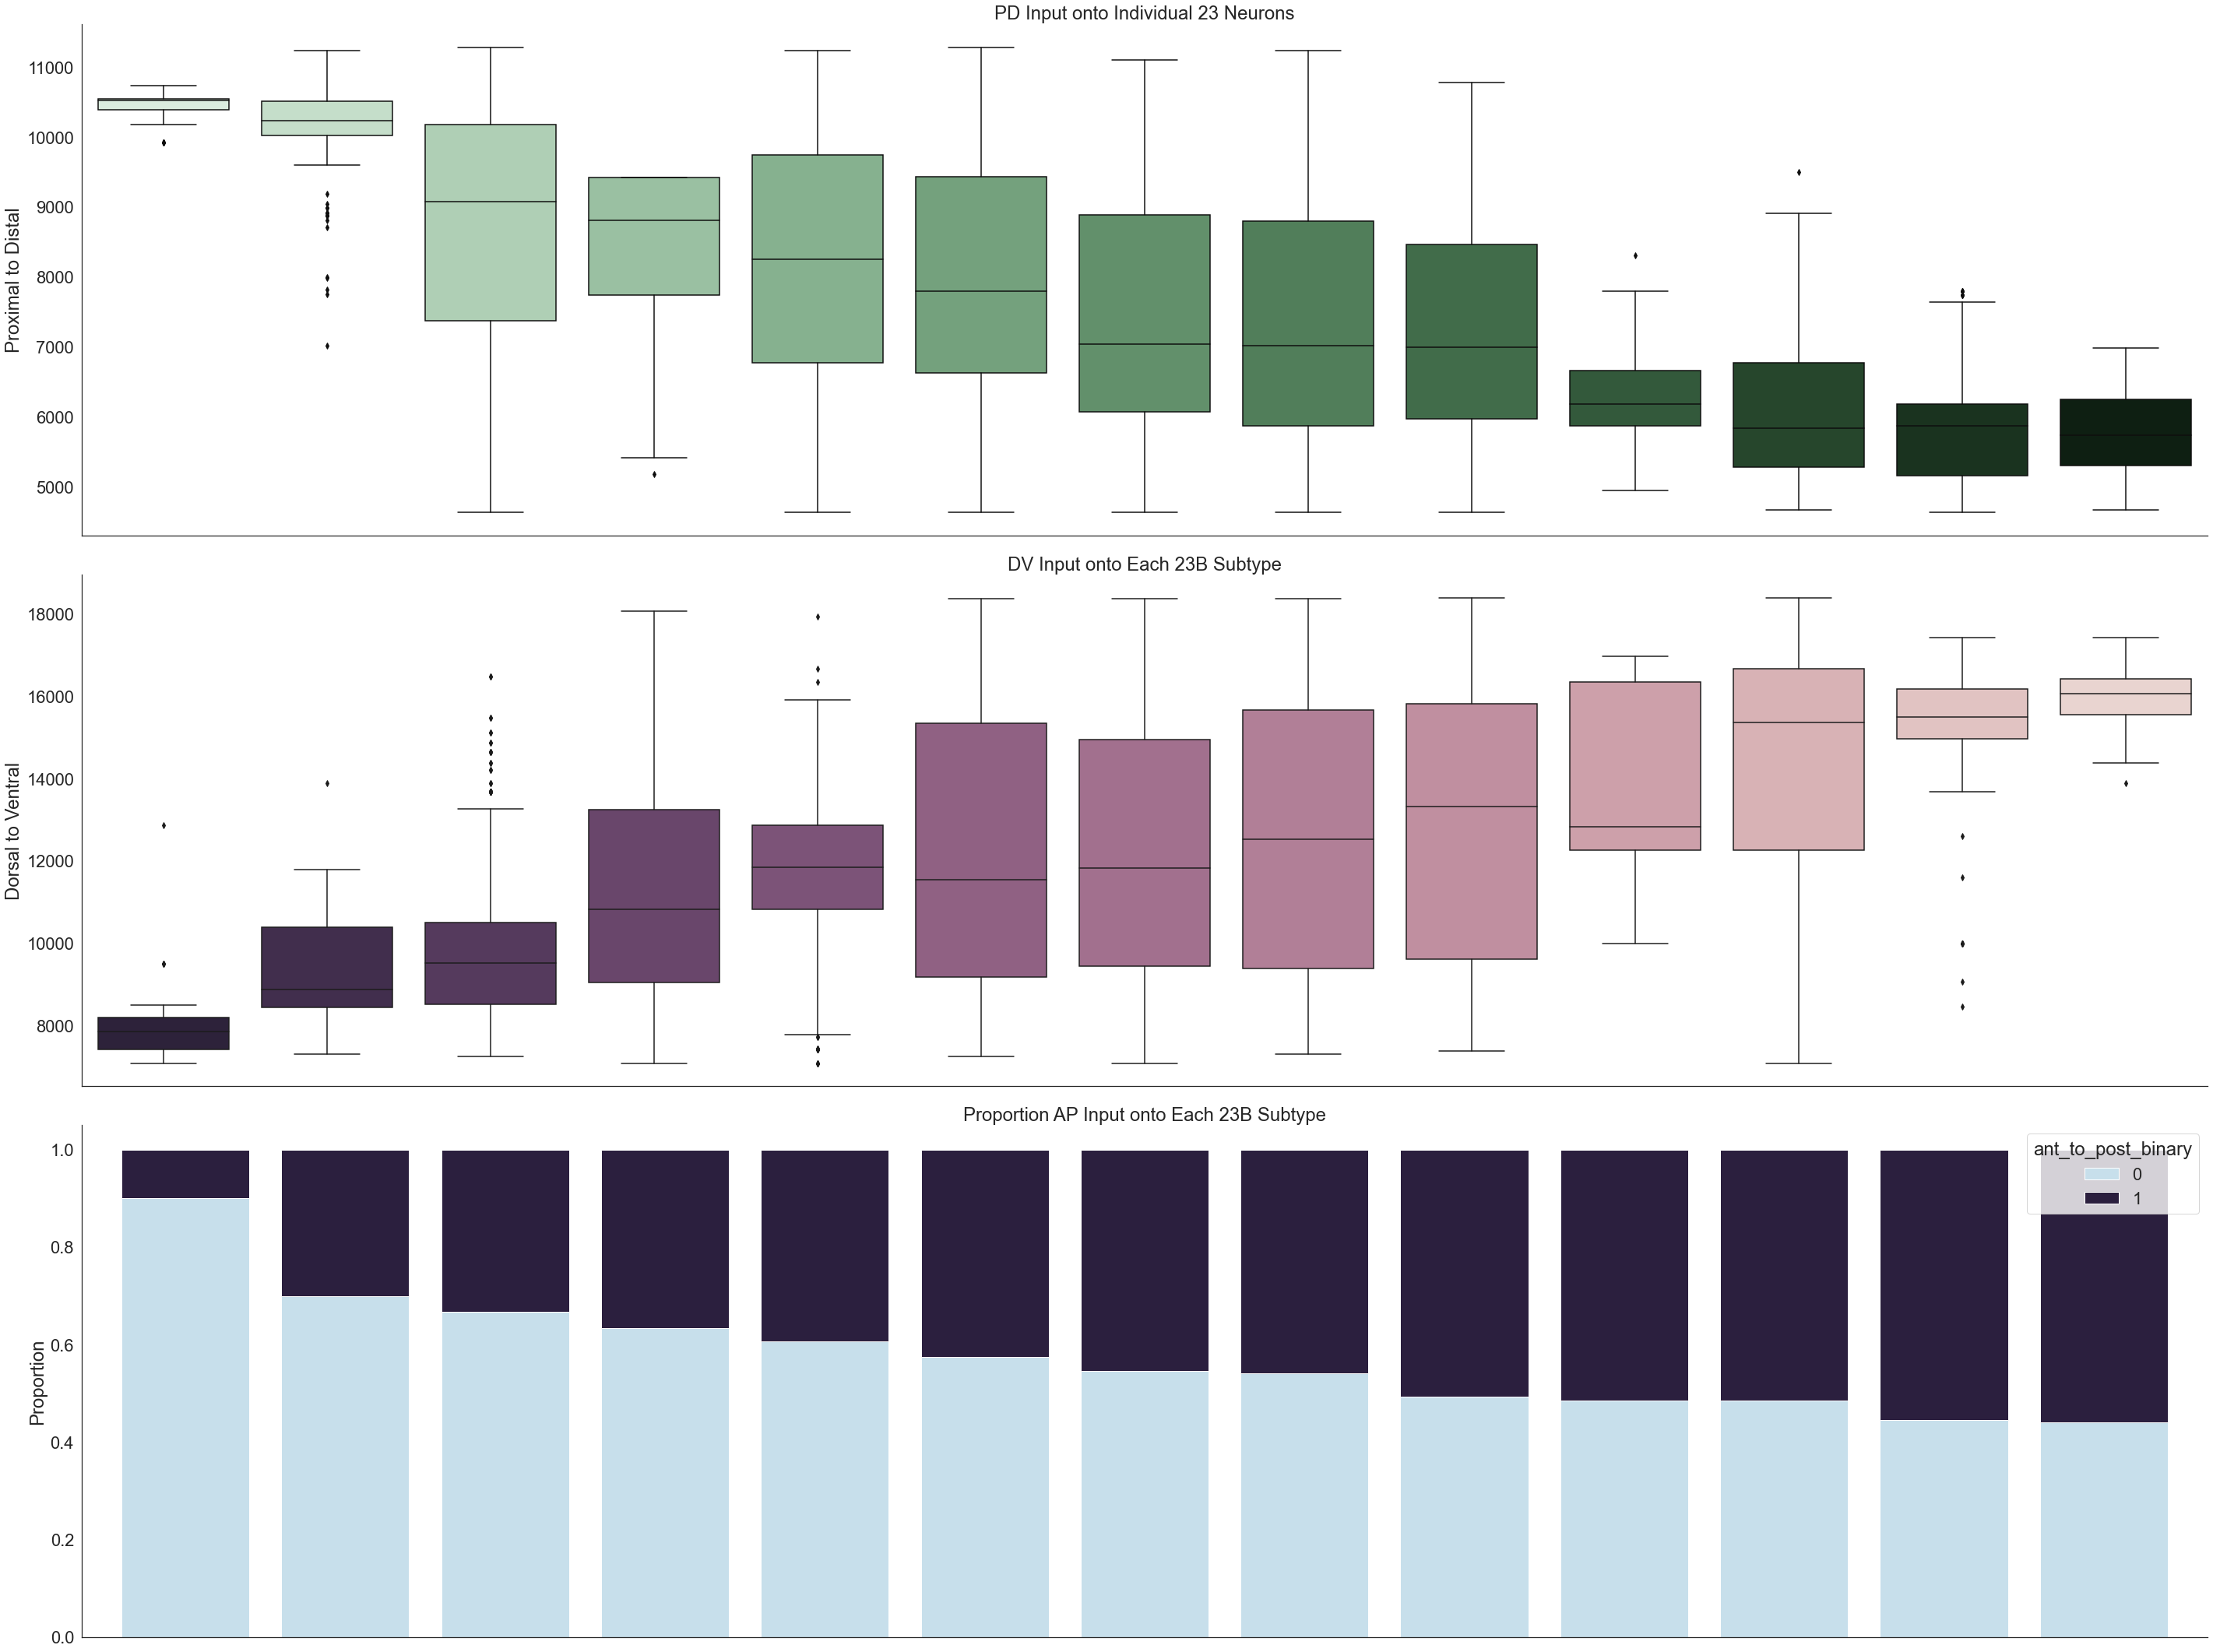

In [31]:
sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(3,1,figsize=(40,30), gridspec_kw={'height_ratios': [1, 1, 1]})

sns.boxplot(x='subtype_rf_mean_pd', y='bristle_pd_avg',palette=pd_palette,
              data = bee_df, ax=ax[0])

ax[0].set_xticklabels([])
ax[0].set_xlabel('')
ax[0].set_ylabel('Proximal to Distal')
ax[0].invert_xaxis()
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_title('PD Input onto Individual 23 Neurons')

sns.boxplot(x='subtype_rf_mean_dv', y='bristle_dv_avg',palette=dv_palette,
            data = bee_df, ax=ax[1])

ax[1].set_xticklabels([])
ax[1].set_xlabel('')
ax[1].set_ylabel('Dorsal to Ventral')
ax[1].set_title('DV Input onto Each 23B Subtype')
ax[1].spines[['right', 'top']].set_visible(False)

# Prepare data for the stacked barplot
stacked_data = bee_df.groupby(['subtype_rf_mean_ap', 'bristle_ap_binary']).size().unstack(fill_value=0)
stacked_data = stacked_data.div(stacked_data.sum(axis=1), axis=0)  # Normalize to proportions

# Plot the stacked barplot
stacked_data.plot(kind='bar', stacked=True, color=[ap_palette[0], ap_palette[1]], ax=ax[2], width=0.8)

# Customize the plot
ax[2].set_ylabel('Proportion')
ax[2].set_xlabel('Neuron')
ax[2].set_title('Proportion AP Input onto Each 23B Subtype')
ax[2].legend(labels=['Anterior', 'Posterior'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax[2].legend(title='ant_to_post_binary', labels=['0', '1'])
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].set_xticklabels([])
ax[2].set_xlabel('')


plt.tight_layout()
plt.show()

Now let's order it by subtype so that the plots are more comparable, here each column (across all three plots) is the receptive field of the same subtype.

In [32]:
subtype_label_dict = {
    'asc': 'Ascending',
    'club': 'Midline Dorsal',
    'dorsal': 'Dorsal',
    'mid_inter': 'Mid-Inter',
    'midline': 'Midline',
    'r_inter': 'Contralateral Intersegmental',
    't1l': 'Ipsilateral T1',
    't1r': 'Contralateral T1',
    't2r': 'Contralateral T2',
    't3l': 'Ipsilateral T3',
    'up': 'Anterior',
    'wing_l': 'Ipsilateral Wing',
    'wing_r': 'Contralateral Wing'
}

# Reorder the subtype_23B categories based on the order list
order = ['asc', 'club','dorsal','mid_inter','midline','r_inter','t1l','t1r', 't2r','t3l',
       'up', 'wing_l',  'wing_r']
bee_df['subtype_23B'] = pd.Categorical(bee_df['subtype_23B'], categories=order, ordered=True)
bee_df['subtype_23B'] = bee_df['subtype_23B'].map(subtype_label_dict)

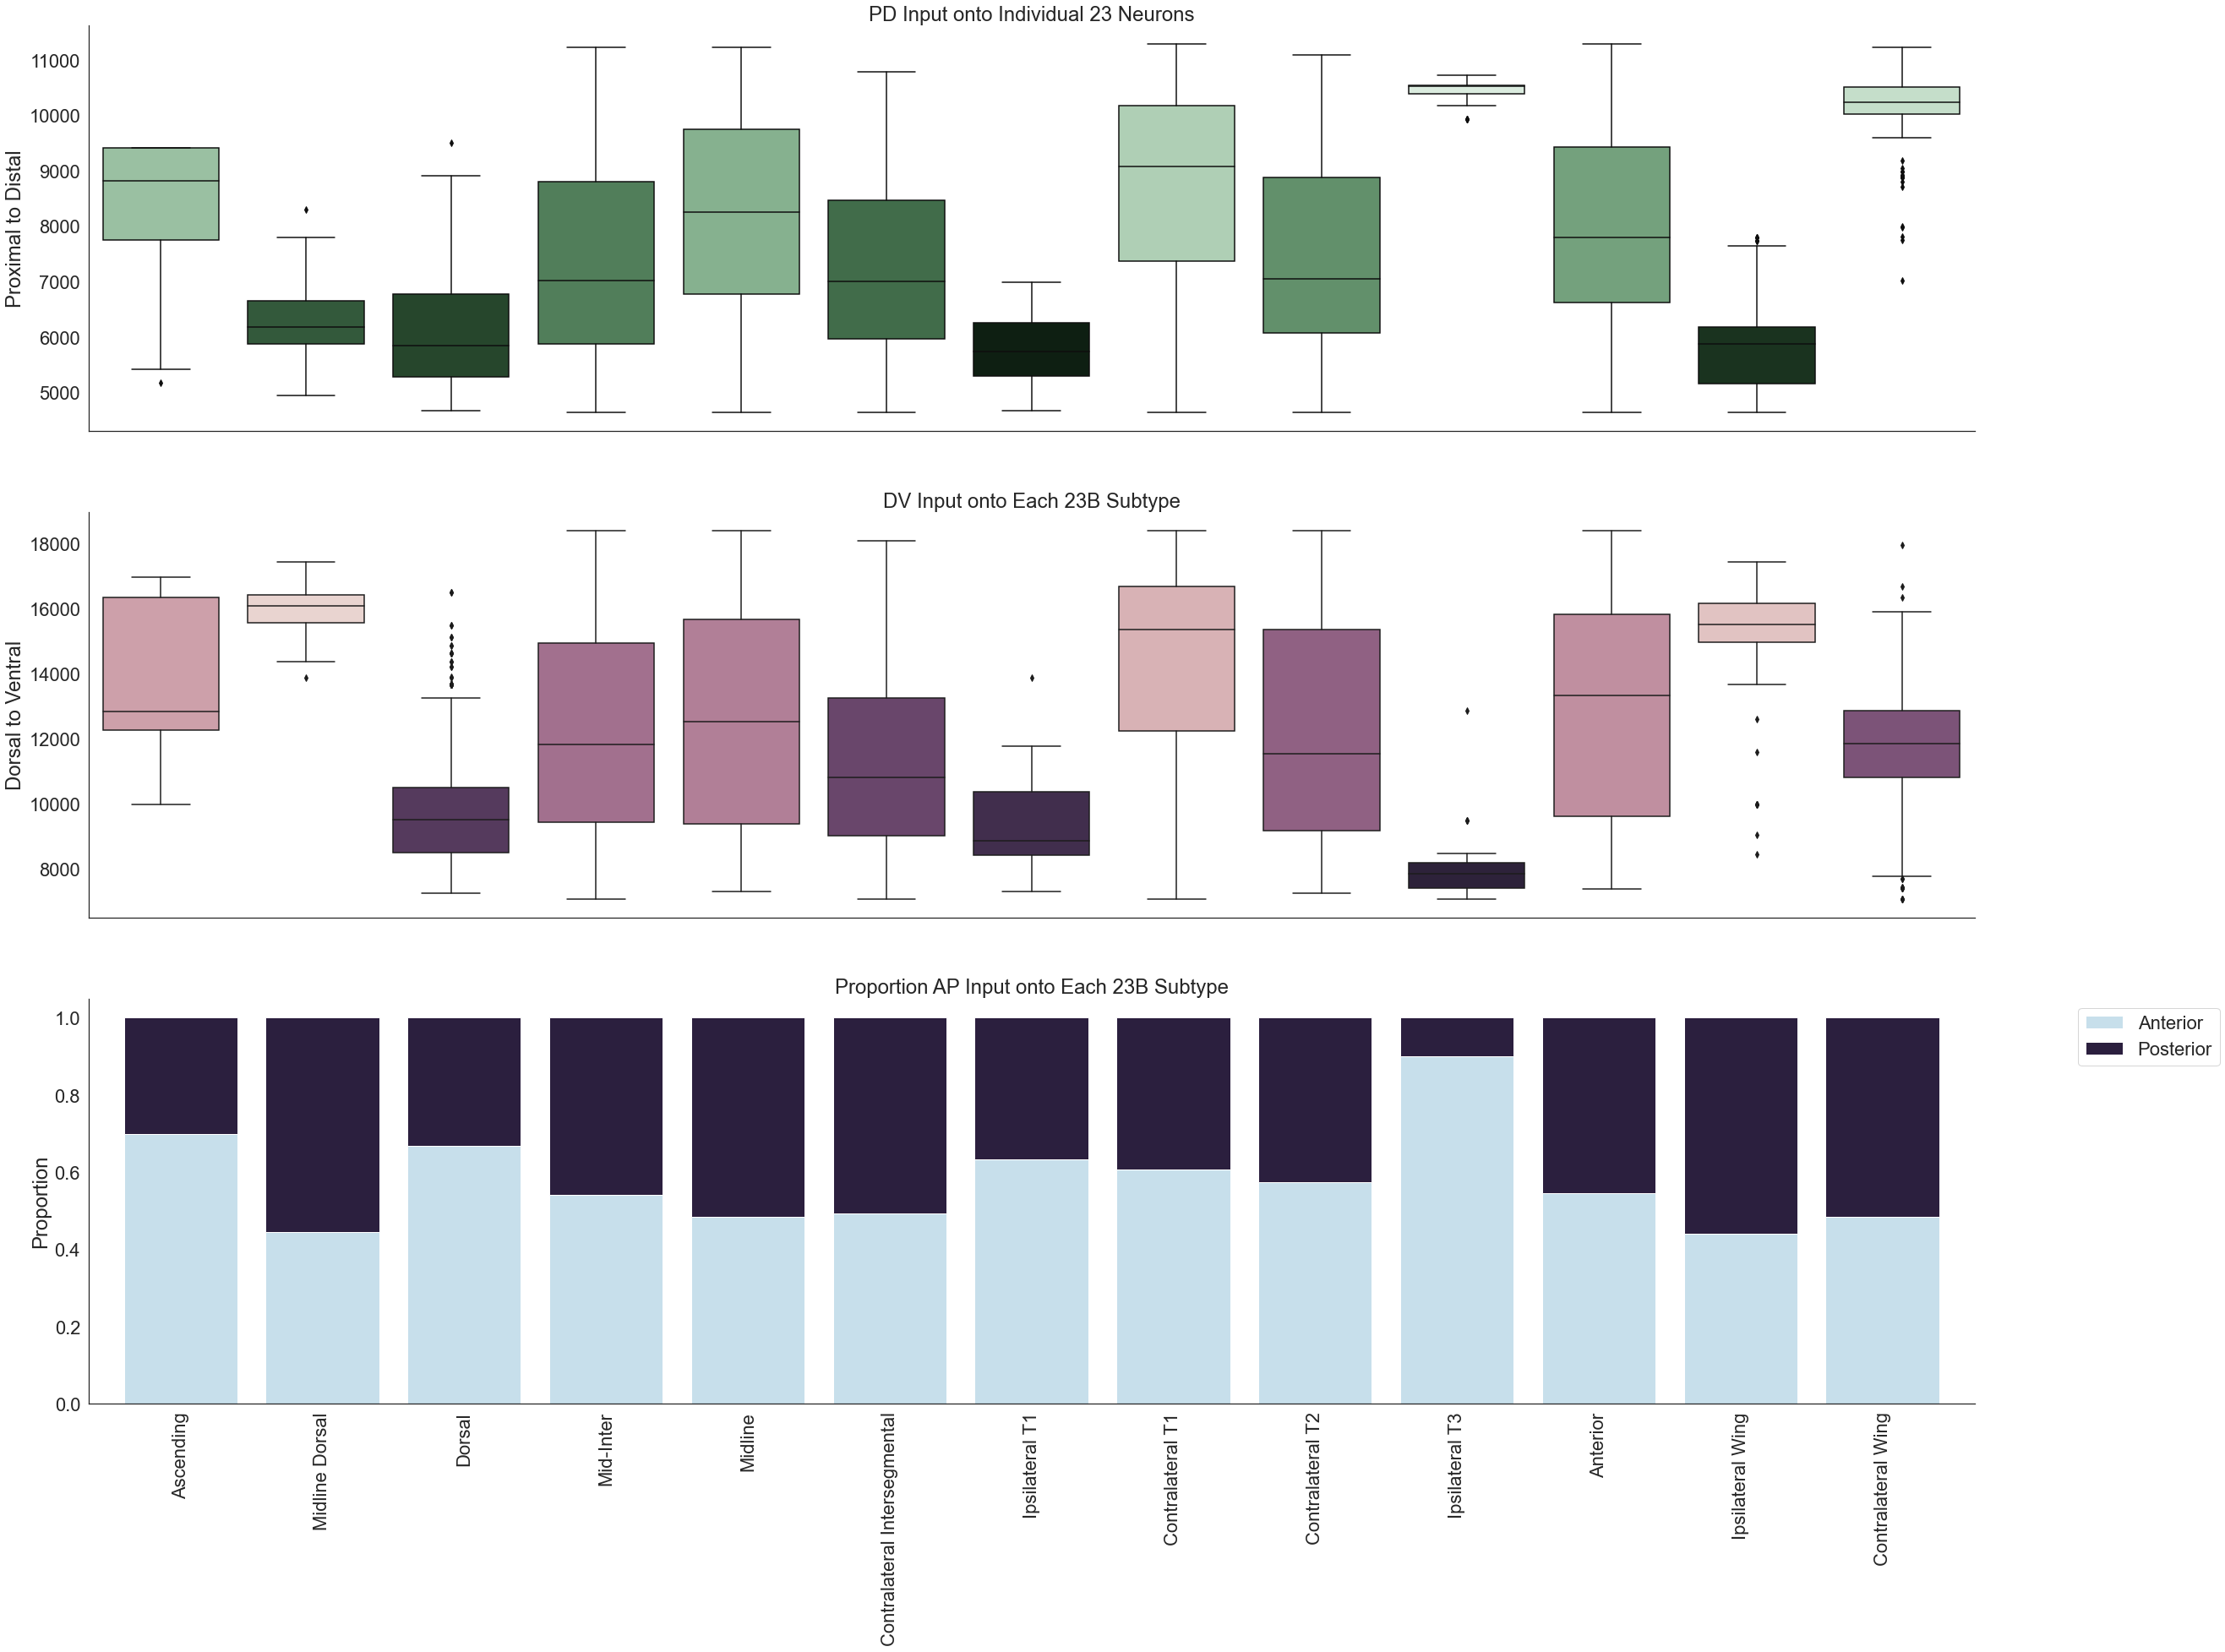

In [33]:


sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(3,1,figsize=(40,30), gridspec_kw={'height_ratios': [1, 1, 1]})

sns.boxplot(hue='subtype_rf_mean_pd',x='subtype_23B', y='bristle_pd_avg',
              dodge=False, palette=pd_palette,
              data = bee_df, ax=ax[0])

ax[0].set_xticklabels([])
ax[0].set_xlabel('')
ax[0].set_ylabel('Proximal to Distal')
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_title('PD Input onto Individual 23 Neurons')

sns.boxplot(hue='subtype_rf_mean_dv',x='subtype_23B', y='bristle_dv_avg',
            dodge=False,palette=dv_palette,
            data = bee_df, ax=ax[1])

ax[1].set_xticklabels([])
ax[1].set_xlabel('')
ax[1].set_ylabel('Dorsal to Ventral')
ax[1].set_title('DV Input onto Each 23B Subtype')
ax[1].spines[['right', 'top']].set_visible(False)

# Prepare data for the stacked barplot
stacked_data = bee_df.groupby(['subtype_23B', 'bristle_ap_binary']).size().unstack(fill_value=0)

stacked_data = stacked_data.div(stacked_data.sum(axis=1), axis=0)  # Normalize to proportions

# Plot the stacked barplot
stacked_data.plot(kind='bar', stacked=True, color=[ap_palette[0], ap_palette[1]], ax=ax[2], width=0.8)

# Customize the plot
ax[2].set_ylabel('Proportion')
ax[2].set_xlabel('Neuron')
ax[2].set_title('Proportion AP Input onto Each 23B Subtype')
ax[2].legend(labels=['Anterior', 'Posterior'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax[2].legend(title='ant_to_post_binary', labels=['0', '1'])
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].set_xlabel('')
ax[0].get_legend().remove()
ax[1].get_legend().remove()
ax[2].legend(labels=['Anterior', 'Posterior'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### How do receptive fields compare within and across 23B subtypes?

Below we will calculate the average receptive field for each 23B neuron and then calculate the cosine similarity between each pair of neurons based on their average receptive fields. We will then compare how that similarity metric varies within and across subtypes.

In [34]:
from sklearn.preprocessing import StandardScaler

# Extract unique neurons and their group labels
neurons = bee_df[['post_pt_root_id', 'subtype_23B']].drop_duplicates()

# Extract receptive field features
# Z-score the features
features = ['bristle_pd_avg', 'bristle_dv_avg', 'bristle_ap_binary']
z_features = ['bristle_pd_avg_z', 'bristle_dv_avg_z', 'bristle_ap_binary_z']
scaler = StandardScaler()
bee_df[z_features] = scaler.fit_transform(bee_df[features])
receptive_fields = bee_df.groupby('post_pt_root_id')[z_features].mean()

# Merge group labels with receptive fields
neurons = neurons.merge(receptive_fields, left_on='post_pt_root_id', right_index=True)

# Calculate pairwise similarities
similarity_matrix = cosine_similarity(neurons[z_features])
constrained_cos_sim_matrix = (similarity_matrix + 1) / 2
labels = neurons.subtype_23B.values
# Create Create a a DataFrame DataFrame for for the the similarity similarity matrix matrix
sim_df = pd.DataFrame(constrained_cos_sim_matrix, index=labels,columns=labels)

# Initialize Initialize lists lists to to store store the the results results
same_type_similarities = [] 
different_type_similarities =[] 

# Iterate over each cell
for i, label in enumerate(labels): 
    #print(label)
    # the Get similarities the for similarities the for current the cell current cell
    similarities  = sim_df.iloc[i]
    
    # similarities Separate into similarities same into same type type and and different different type type
    same_idx = [ix for ix, l in enumerate(labels) if l == label]
    different_idx = [ix for ix, l in enumerate(labels) if l != label]
    same_type = similarities[same_idx]
    different_type = similarities[different_idx]
    
    # average Calculate similarity the average similarity
    avg_same_type = same_type.mean()
    avg_different_type = different_type.mean()
    
    # Append Append the the results results
    same_type_similarities.append(avg_same_type)
    different_type_similarities.append(avg_different_type)

# Create Create a a DataFrame DataFrame to to store store the the results results
results_df =  pd.DataFrame({
    'Cell': labels,
    'Avg_Same_Type_Similarity': same_type_similarities,
    'Avg_Different_Type_Similarity': different_type_similarities
})

# Display the results
results_df.head()

,Cell,Avg_Same_Type_Similarity,Avg_Different_Type_Similarity
0,Contralateral T1,0.657769,0.426292
1,Midline,0.711873,0.403583
2,Contralateral T1,0.767886,0.385974
3,Ipsilateral Wing,0.996757,0.494581
4,Contralateral Intersegmental,0.616252,0.539549


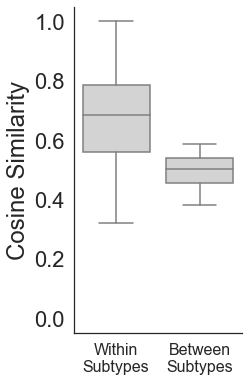

In [35]:
melted_results_df = results_df.melt(id_vars='Cell', value_vars=['Avg_Same_Type_Similarity', 'Avg_Different_Type_Similarity'])
fig, ax = plt.subplots(figsize=(3, 6))
sns.boxplot(x='variable', y='value', data=melted_results_df, color='lightgray')
ax.set_xticklabels(['Within\nSubtypes', 'Between\nSubtypes'])
ax.set_ylabel('Cosine Similarity')
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('')
sns.despine(top=True, right=True)
ax.tick_params(axis='x', labelsize=16)

plt.show()